In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

import scipy.io.wavfile as wavfile
import scipy.signal as signal
import sounddevice

def getSamples(tList, fct, f, a = 1, phi = 0):
    return [fct(t, f, a, phi) for t in tList]

def pltStemWrapper(timeAxis, fct, f, a = 1, phi = 0):
    plt.stem(timeAxis, getSamples(timeAxis, fct, f, a, phi))
    
def pltPlotWrapper(timeAxis, fct, f, a = 1, phi = 0):
    plt.plot(timeAxis, getSamples(timeAxis, fct, f, a, phi))


In [2]:
def signalSin(t, f, a, phi):
    return a*np.sin(2*np.pi*f*t + phi)

def signalCos(t, f, a, phi):
    return a*np.cos(2*np.pi*f*t + phi)

def signalSawtooth(t, f, a, phi):
    return a*np.mod(2*f*np.pi*t + phi, 2*np.pi)

def signalSquare(t, f, a, phi):
    return np.sign(semnalSin(t, f, a, phi))

def signalIdentity(t):
    return t


In [3]:
class Axis:
    def __init__(self, time_of_view = 1, sampling_rate = 441e2):
        self.time_of_view = time_of_view                          # seconds
        
        self.sampling_rate = sampling_rate                        # Hertz
        self.sampling_period = 1./self.sampling_rate              # seconds
        self.n_samples = self.time_of_view/self.sampling_period   # no unit of measure 
        
        self.time = np.linspace (0, self.time_of_view, int(self.n_samples + 1), dtype = 'complex_')  # seconds
        

In [13]:
class Signal:
    def __init__(self, axis, frequency = 440, amplitude = 1e4, phase = 0, w = 1):
        self.axis = axis
        self.frequency = frequency                                # Hertz
        self.amplitude = amplitude                                # meters
        self.phase = phase                                        # radians
        
        self.w = w
        self.signal = [(math.e ** (-2.0 * np.pi * 1j * w * t)) * self.sin(self.amplitude, self.frequency, t, self.phase) for t in self.axis.time]
        
    def stem(self):
        plt.grid(True)
        plt.stem (self.axis.time, self.signal)
        
    def plot(self):
        plt.grid(True)
        plt.plot (self.axis.time, self.signal)
        
    def stemRealImag(self):
        plt.grid(True)
        reals = [x.real for x in self.signal]
        imags = [x.imag for x in self.signal]
        plt.stem (reals, imags)
    
    def plotRealImag(self):
        plt.grid(True)
        reals = [x.real for x in self.signal]
        imags = [x.imag for x in self.signal]
        plt.plot (reals, imags)
    
    @classmethod
    def sin(cls, amplitude, frequency, time, phase):
        return float(amplitude) * np.sin (2.0 * np.pi * frequency * time + float(phase))
    
    # sum pe toate esantioanele din semnal   ori expoinentiala de data trecuta/N(nr esantioane)
        ####self.fourier = sum([(math.e ** (-2.0 * np.pi * 1j * w * t / self.axis.time_of_view)) * self.sin(self.amplitude, self.frequency, t, self.phase) for t in self.axis.time])
            


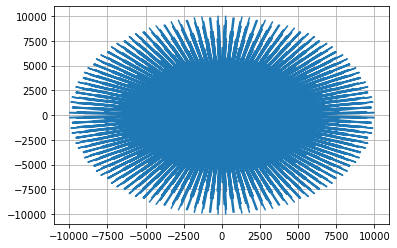

In [14]:
# ex 1
axis1 = Axis(sampling_rate = 1000) 
signal1 = Signal(axis1, w = 1)

signal1.plotRealImag()


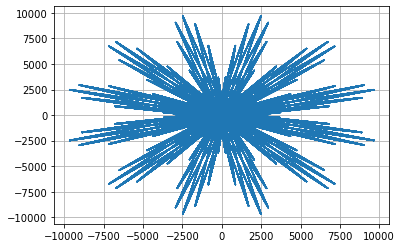

In [15]:
axis1 = Axis(sampling_rate = 1000) 
signal1 = Signal(axis1, w = 10)

signal1.plotRealImag()


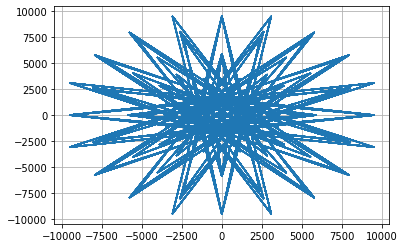

In [16]:
axis1 = Axis(sampling_rate = 1000) 
signal1 = Signal(axis1, w = 50)

signal1.plotRealImag()


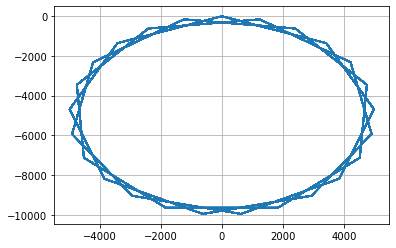

In [17]:
axis1 = Axis(sampling_rate = 1000) 
signal1 = Signal(axis1, w = 440)

signal1.plotRealImag()


In [18]:
# ex 2
axis2 = Axis(sampling_rate = 1000)

signal2a = Signal(axis2, w = 440, amplitude = 2)
signal2b = Signal(axis2, w = 220, amplitude = 5)
signal2c = Signal(axis2, w = 150, amplitude = 4)

signals2 = [signal2a, signal2b, signal2c]

def composed_signal(t, signals):
    result = 0
    for signal in signals:
        result += signal.sin(signal.amplitude, signal.frequency, t, signal.phase)
    return result

w = 440
fourier = sum([(math.e ** (-2.0 * np.pi * 1j * w * t / axis2.time_of_view)) * composed_signal(t, signals2) for t in axis2.time])
print(abs(fourier)) 


5499.999999999954
